# Cloud Coverage Classification over Ocean Surfaces Using Sentinel-3 OLCI Imagery




### Mount Google Drive and set data path

This section mounts Google Drive and defines the path to the Sentinel-3 OLCI Level-1 EFR product folder used in this project.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
nc_dir = '/content/drive/MyDrive/AI/Week10/S3B_OLCI_CloudSea_20240707.SEN3/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Convert Sentinel-3 OLCI NetCDF bands into a NumPy array
This section installs the required packages and converts the Sentinel-3 OLCI Level-1 EFR radiance bands from NetCDF format into NumPy arrays for later classification.


In [2]:
!pip install netCDF4 basemap

### Convert Sentinel-3 OLCI radiance bands from NetCDF to NumPy

This section reads the 21 Sentinel-3 OLCI Level-1 EFR radiance files, from `Oa01_radiance.nc` to `Oa21_radiance.nc`, and combines them into a single NumPy array. The radiance uncertainty files, such as `Oa01_radiance_unc.nc`, are not used in this workflow.

Each pixel is represented by 21 spectral-band values, which will be used as input features for the cloud and sea-surface classification models. The converted array is saved as `radiance.npy` in the output folder, and quick-look images of each OLCI band are also saved for visual inspection.

In [3]:
# -*- coding: utf-8 -*-

from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import os

# Output folder for converted NumPy data and quick-look band images
out_dir = '/content/drive/MyDrive/AI/Week10/outputs/'
os.makedirs(out_dir, exist_ok=True)


def nc2npy(path):
    """
    Read one Sentinel-3 OLCI NetCDF radiance file and return it as a NumPy array.
    """
    nc_file = Dataset(path)
    print(nc_file)

    # Get the variable name from the file name, e.g. Oa01_radiance.nc -> Oa01_radiance
    var_name = path.split('/')[-1].replace('.nc', '')
    arr = nc_file.variables[var_name][:]
    arr = np.array(arr)

    # Replace fill values with zero
    if 'unc' in path:
        arr[np.where(arr == 255)] = 0
    else:
        arr[np.where(arr == 65535)] = 0

    print("max:", arr.max(), "min:", arr.min(), "mean:", arr.mean())

    nc_file.close()
    return arr


def main():
    for subset in ['radiance']:
        res = []

        for i in range(1, 22):
            file_path = os.path.join(nc_dir, "Oa%02d_%s.nc" % (i, subset))
            print("Reading:", file_path)

            arr = nc2npy(file_path)
            res.append(arr)

            # Save quick-look image for each band
            plt.imsave(os.path.join(out_dir, "Oa%02d_radiance.png" % i), arr)

        # Stack all 21 bands into one NumPy array
        # Final shape should be height x width x 21
        res = np.stack(res, axis=-1)
        print("Stacked array shape:", res.shape)

        # Save combined 21-band array
        np.save(os.path.join(out_dir, "%s.npy" % subset), res)
        print("Saved successfully to:", os.path.join(out_dir, "%s.npy" % subset))


main()


Reading: /content/drive/MyDrive/AI/Week10/S3B_OLCI_CloudSea_20240707.SEN3/Oa01_radiance.nc
<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    absolute_orbit_number: 32292
    ac_subsampling_factor: 64
    al_subsampling_factor: 1
    comment:  
    contact: ops@eumetsat.int
    creation_time: 2024-09-21T17:35:53Z
    history:   2024-09-21T17:35:53Z: PUGCoreProcessor /repvol/JOBTMPDIR_s3b-s3pug-efr_612.1216_4864_i70xag5r/WD_S3B_OL1-1720346591.765536_1720349254.188487_20240921173406/JobOrder.xml
    institution: MAR
    netCDF_version: 4.2 of Apr 12 2021 08:07:42 $
    processing_baseline: OL__L1_.004.00.00
    product_name: S3B_OL_1_EFR____20240707T101616_20240707T101916_20240921T173553_0179_095_065_1980_MAR_R_NT_004.SEN3
    references: S3IPF PDS 004.1 - i2r6 - Product Data Format Specification - OLCI Level 1, S3IPF PDS 002 - i1r8 - Product Data Format Specification - Product Structures, S3IPF DPM 002 - i2r9 - Detailed Processing Model - OLCI Level 1
    r

### Split the converted OLCI array into smaller chunks

This section splits the converted 21-band Sentinel-3 OLCI NumPy array into five smaller chunks. This reduces memory use during later processing and makes it easier to train and test the classification models on large satellite imagery.

In [4]:
import os
import numpy as np

# Output folder used in the previous section
out_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

def split_npy(data, num_splits, save_dir, prefix='chunk'):
    """
    Split a large NumPy array into smaller chunks along the row dimension.
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    chunks = np.array_split(data, num_splits, axis=0)

    for i, chunk in enumerate(chunks):
        save_path = os.path.join(save_dir, f"{prefix}_{i+1}.npy")
        np.save(save_path, chunk)
        print(f"Saved chunk {i+1} to {save_path}, shape = {chunk.shape}")


# Load the converted 21-band OLCI radiance array
data = np.load(os.path.join(out_dir, 'radiance.npy'))

print("Original data shape:", data.shape)

# Save chunks into the output folder
split_npy(
    data,
    num_splits=5,
    save_dir=out_dir,
    prefix='radiance_chunk'
)


Original data shape: (4090, 4865, 21)
Saved chunk 1 to /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_1.npy, shape = (818, 4865, 21)
Saved chunk 2 to /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_2.npy, shape = (818, 4865, 21)
Saved chunk 3 to /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_3.npy, shape = (818, 4865, 21)
Saved chunk 4 to /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_4.npy, shape = (818, 4865, 21)
Saved chunk 5 to /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_5.npy, shape = (818, 4865, 21)


### Visualise and save the split OLCI chunks

This section loads the converted Sentinel-3 OLCI radiance array, splits it into five smaller chunks, and visualises the first spectral band of each chunk. The chunks are saved separately to reduce memory use in later processing.

Data shape: (4090, 4865, 21)
Chunk 1 shape: (818, 4865, 21)


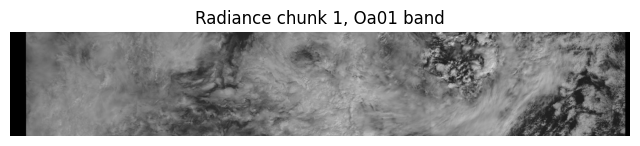

Chunk 2 shape: (818, 4865, 21)


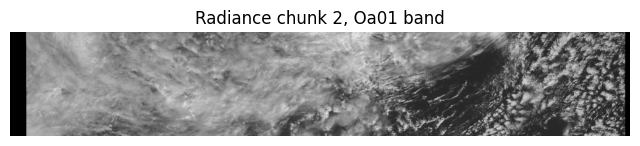

Chunk 3 shape: (818, 4865, 21)


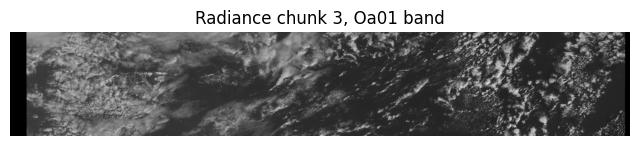

Chunk 4 shape: (818, 4865, 21)


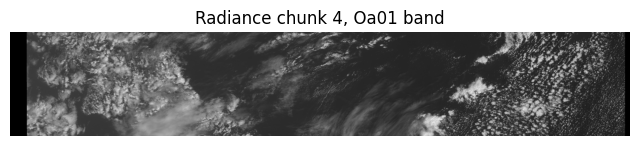

Chunk 5 shape: (818, 4865, 21)


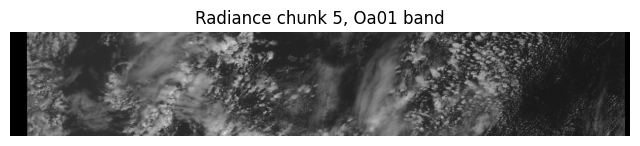

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder where radiance.npy and chunk files are saved
out_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Load converted OLCI radiance array
data = np.load(os.path.join(out_dir, 'radiance.npy'))

print(f"Data shape: {data.shape}")

# Split data into 5 chunks along the row dimension
chunks = np.array_split(data, 5, axis=0)

for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} shape: {chunk.shape}")

    # Save each chunk
    chunk_path = os.path.join(out_dir, f"radiance_chunk_{i+1}.npy")
    np.save(chunk_path, chunk)

    # Display the first OLCI band in each chunk
    plt.figure(figsize=(8, 4))
    plt.imshow(chunk[:, :, 0], cmap='gray')
    plt.title(f"Radiance chunk {i+1}, Oa01 band")
    plt.axis("off")
    plt.show()

### Generate training and testing data from a selected OLCI chunk

In [6]:
# Import packages needed for preparing training and testing data
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [7]:
# Specify path to the converted OLCI NumPy files
datadir = '/content/drive/MyDrive/AI/Week10/outputs/'

### Create an automatic binary mask for the selected OLCI chunk

This section creates an automatic binary mask for the selected Sentinel-3 OLCI chunk using a simple brightness threshold. Cloud-covered pixels are generally brighter than clear sea-surface pixels in visible OLCI bands, so pixels above the threshold are labelled as cloud and pixels below the threshold are labelled as sea.

The mask uses two classes:

- `0` = clear sea surface
- `1` = cloud-covered pixels

The generated mask is saved as `mask_chunk_4.png` and will be used as the label data for supervised classification.

Loaded image shape: (818, 4865, 21)


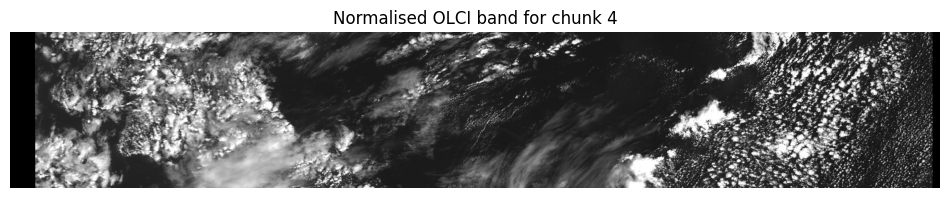

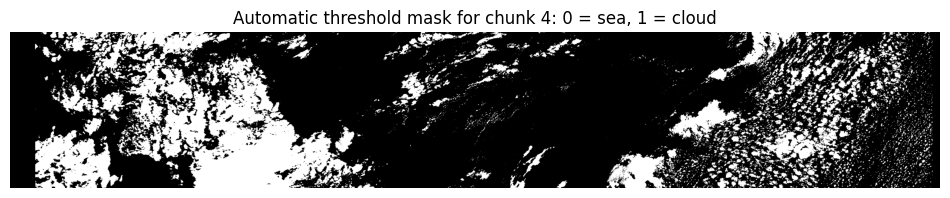

Saved automatic mask to: /content/drive/MyDrive/AI/Week10/outputs/mask_chunk_4.png
Mask class counts: {np.uint8(0): np.int64(2974673), np.uint8(1): np.int64(1004897)}


In [4]:
# Create an automatic binary mask for the selected OLCI chunk

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Folder where converted NumPy files are stored
datadir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Select the chunk used for training
chunk_id = 4

# Load selected OLCI chunk
image = np.load(os.path.join(datadir, f'radiance_chunk_{chunk_id}.npy'))

print("Loaded image shape:", image.shape)

# Use one visible OLCI band for thresholding.
# Oa05 is used because visible bands show strong contrast between bright clouds and darker sea surface.
band = image[:, :, 4].astype(float)

# Normalise the band for display and thresholding
p2, p98 = np.nanpercentile(band, (2, 98))
band_norm = np.clip((band - p2) / (p98 - p2), 0, 1)

# Bright pixels are classified as cloud, darker pixels as sea
threshold = 0.45
binary_mask = np.where(band_norm > threshold, 1, 0).astype(np.uint8)

# Show the normalised band
plt.figure(figsize=(12, 4))
plt.imshow(band_norm, cmap='gray')
plt.title(f"Normalised OLCI band for chunk {chunk_id}")
plt.axis("off")
plt.show()

# Show the automatically generated mask
plt.figure(figsize=(12, 4))
plt.imshow(binary_mask, cmap='gray')
plt.title(f"Automatic threshold mask for chunk {chunk_id}: 0 = sea, 1 = cloud")
plt.axis("off")
plt.show()

# Save mask as PNG
mask_path = os.path.join(datadir, f'mask_chunk_{chunk_id}.png')
cv2.imwrite(mask_path, binary_mask * 255)

print("Saved automatic mask to:", mask_path)

# Print class counts
unique, counts = np.unique(binary_mask, return_counts=True)
print("Mask class counts:", dict(zip(unique, counts)))

### Create labelled training and testing samples from the selected OLCI chunk

This section loads one selected Sentinel-3 OLCI data chunk and its corresponding automatically generated threshold mask. The mask defines two classes: clear sea surface and cloud-covered pixels. A small 3 × 3 spatial patch is extracted around each labelled pixel, and the resulting samples are split into training and testing datasets.

Loaded image: /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_4.npy
Image shape: (818, 4865, 21)


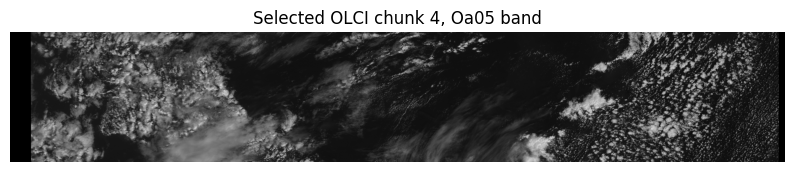

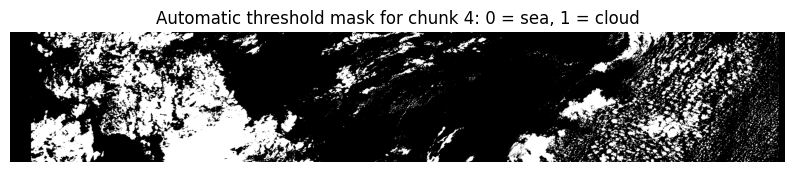

Image shape: (818, 4865, 21)
Mask shape: (818, 4865)
Patches shape: (3968208, 3, 3, 21)
Labels shape: (3968208,)
Class counts before balancing: {np.uint8(0): np.int64(2965893), np.uint8(1): np.int64(1002315)}
Sea samples: 2965893
Cloud samples: 1002315
Samples used per class: 1002315
Training class counts: {np.uint8(0): np.int64(902083), np.uint8(1): np.int64(902084)}
Testing class counts: {np.uint8(0): np.int64(100232), np.uint8(1): np.int64(100231)}
X_train_balanced shape: (1804167, 3, 3, 21)
X_test_balanced shape: (200463, 3, 3, 21)
y_train_balanced shape: (1804167,)
y_test_balanced shape: (200463,)


In [5]:
# Generate training and testing data from the selected OLCI chunk

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Folder where converted NumPy files and mask are stored
datadir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Select the chunk used for training
chunk_id = 4

# Load the selected OLCI chunk
image_path = os.path.join(datadir, f'radiance_chunk_{chunk_id}.npy')
image = np.load(image_path)

print("Loaded image:", image_path)
print("Image shape:", image.shape)

# Load the automatically generated binary mask
# black = sea = 0
# white = cloud = 1
mask_path = os.path.join(datadir, f'mask_chunk_{chunk_id}.png')

if not os.path.exists(mask_path):
    raise FileNotFoundError(
        f"Mask not found: {mask_path}\n"
        f"Please create the automatic mask mask_chunk_{chunk_id}.png before running this cell."
    )

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Resize mask if needed
if mask.shape != image.shape[:2]:
    print("Mask shape before resize:", mask.shape)
    print("Image shape:", image.shape[:2])
    mask = cv2.resize(
        mask,
        (image.shape[1], image.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )
    print("Mask resized to:", mask.shape)

# Convert mask into binary labels
# white pixels = cloud = 1
# black pixels = sea = 0
binary_mask = np.where(mask > 127, 1, 0).astype(np.uint8)

# Visual check: OLCI band and mask
plt.figure(figsize=(10, 4))
plt.imshow(image[:, :, 4], cmap='gray')
plt.title(f"Selected OLCI chunk {chunk_id}, Oa05 band")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(binary_mask, cmap='gray')
plt.title(f"Automatic threshold mask for chunk {chunk_id}: 0 = sea, 1 = cloud")
plt.axis("off")
plt.show()

print("Image shape:", image.shape)
print("Mask shape:", binary_mask.shape)

# Extract 3 × 3 × 21 patches around each labelled pixel
patches = []

for i in range(1, image.shape[0] - 1):
    for j in range(1, image.shape[1] - 1):
        patch = image[i-1:i+2, j-1:j+2, :]
        patches.append(patch)

patches_array = np.array(patches)

# Trim mask boundary pixels to match 3 × 3 patch extraction
trimmed_mask = binary_mask[1:-1, 1:-1]
labels = trimmed_mask.flatten()

print("Patches shape:", patches_array.shape)
print("Labels shape:", labels.shape)

# Check class distribution before balancing
unique, counts = np.unique(labels, return_counts=True)
print("Class counts before balancing:", dict(zip(unique, counts)))

# Balance sea and cloud classes automatically
indices_class_0 = np.where(labels == 0)[0]  # sea
indices_class_1 = np.where(labels == 1)[0]  # cloud

num_class = min(len(indices_class_0), len(indices_class_1))

print("Sea samples:", len(indices_class_0))
print("Cloud samples:", len(indices_class_1))
print("Samples used per class:", num_class)

np.random.seed(42)

sampled_indices_class_0 = np.random.choice(indices_class_0, num_class, replace=False)
sampled_indices_class_1 = np.random.choice(indices_class_1, num_class, replace=False)

combined_indices = np.concatenate([
    sampled_indices_class_0,
    sampled_indices_class_1
])

np.random.shuffle(combined_indices)

balanced_patches = patches_array[combined_indices]
balanced_labels = labels[combined_indices]

# Split the balanced dataset into training and testing sets
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(
    balanced_patches,
    balanced_labels,
    test_size=0.1,
    random_state=42,
    stratify=balanced_labels
)

# Check class balance after splitting
unique, counts = np.unique(y_train_balanced, return_counts=True)
print("Training class counts:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test_balanced, return_counts=True)
print("Testing class counts:", dict(zip(unique, counts)))

print("X_train_balanced shape:", X_train_balanced.shape)
print("X_test_balanced shape:", X_test_balanced.shape)
print("y_train_balanced shape:", y_train_balanced.shape)
print("y_test_balanced shape:", y_test_balanced.shape)

### Save the balanced training and testing datasets

This section saves the balanced training and testing arrays as NumPy files. These files will be used as inputs for the supervised classification models.

In [11]:
# Save balanced training and testing datasets

import os
import numpy as np

datadir = '/content/drive/MyDrive/AI/Week10/outputs/'

np.save(os.path.join(datadir, 'X_train_balanced.npy'), X_train_balanced)
np.save(os.path.join(datadir, 'X_test_balanced.npy'), X_test_balanced)
np.save(os.path.join(datadir, 'y_train_balanced.npy'), y_train_balanced)
np.save(os.path.join(datadir, 'y_test_balanced.npy'), y_test_balanced)

print("Saved balanced training and testing datasets to:", datadir)

print("Saved files:")
print("X_train_balanced.npy")
print("X_test_balanced.npy")
print("y_train_balanced.npy")
print("y_test_balanced.npy")

Saved balanced training and testing datasets to: /content/drive/MyDrive/AI/Week10/outputs/
Saved files:
X_train_balanced.npy
X_test_balanced.npy
y_train_balanced.npy
y_test_balanced.npy


### Load the saved training and testing datasets

This section loads the balanced training and testing datasets generated in the previous section. These arrays will be used as inputs for the supervised classification models.

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [13]:
# Load the saved balanced training and testing datasets

import os
import numpy as np

data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

X_train = np.load(os.path.join(data_dir, 'X_train_balanced.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test_balanced.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train_balanced.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test_balanced.npy'))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("Training class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Testing class counts:", dict(zip(*np.unique(y_test, return_counts=True))))

X_train shape: (1804167, 3, 3, 21)
X_test shape: (200463, 3, 3, 21)
y_train shape: (1804167,)
y_test shape: (200463,)
Training class counts: {np.uint8(0): np.int64(902083), np.uint8(1): np.int64(902084)}
Testing class counts: {np.uint8(0): np.int64(100232), np.uint8(1): np.int64(100231)}


### Convolutional Neural Network classification

This section trains a simple CNN classifier using the balanced 3 × 3 × 21 OLCI image patches. The model performs binary classification between clear sea-surface pixels and cloud-covered pixels.

In [14]:
!pip install keras

In [7]:
# Train a CNN classifier for cloud and sea-surface classification

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Load saved balanced training and testing datasets
X_train = np.load(os.path.join(data_dir, 'X_train_balanced.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test_balanced.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train_balanced.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test_balanced.npy'))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Convert data type for TensorFlow
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

# Normalise input data using training-set statistics
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Define a simple CNN model for binary classification
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(3, 3, 21)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=4,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print("CNN test loss:", loss)
print("CNN test accuracy:", accuracy)

# Save the model
cnn_model_path = os.path.join(data_dir, 'cnn_cloud_sea_model.keras')
model.save(cnn_model_path)

print("Saved CNN model to:", cnn_model_path)

X_train shape: (1804167, 3, 3, 21)
X_test shape: (200463, 3, 3, 21)
y_train shape: (1804167,)
y_test shape: (200463,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 3, 3, 16)       │         3,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,713 (30.13 KB)

 Trainable params: 7,713 (30.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
6343/6343 ━━━━━━━━━━━━━━━━━━━━ 59s 9ms/step - accuracy: 0.9960 - loss: 0.0100 - val_accuracy: 0.9957 - val_loss: 0.0096
Epoch 2/4
6343/6343 ━━━━━━━━━━━━━━━━━━━━ 52s 8ms/step - accuracy: 0.9975 - loss: 0.0058 - val_accuracy: 0.9981 - val_loss: 0.0045
Epoch 3/4
6343/6343 ━━━━━━━━━━━━━━━━━━━━ 58s 9ms/step - accuracy: 0.9979 - loss: 0.0049 - val_accuracy: 0.9968 - val_loss: 0.0082
Epoch 4/4
6343/6343 ━━━━━━━━━━━━━━━━━━━━ 58s 9ms/step - accuracy: 0.9981 - loss: 0.0045 - val_accuracy: 0.9982 - val_loss: 0.0041
6265/6265 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9982 - loss: 0.0043
CNN test loss: 0.004348656162619591
CNN test accuracy: 0.9981692433357239
Saved CNN model to: /content/drive/MyDrive/AI/Week10/outputs/cnn_cloud_sea_model.keras


### Apply the trained CNN model to the selected OLCI chunk

This section applies the trained CNN model to the full selected Sentinel-3 OLCI chunk. The model predicts whether each pixel belongs to clear sea surface or cloud-covered area. The resulting classification map is saved as a PNG file for later comparison and visual interpretation.

Loaded chunk: /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_4.npy
Chunk shape: (818, 4865, 21)
Loaded CNN model: /content/drive/MyDrive/AI/Week10/outputs/cnn_cloud_sea_model.keras
Prediction input shape: (3968208, 3, 3, 21)
Training mean and std not found, used full chunk statistics.
7751/7751 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step


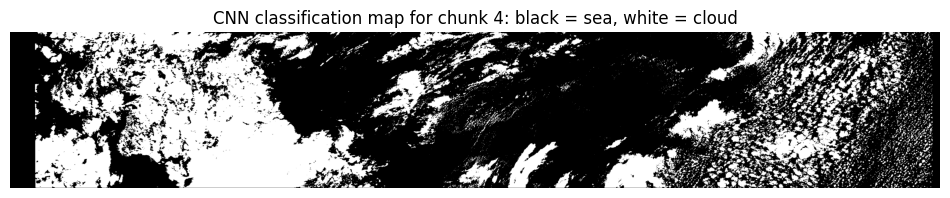

Saved CNN classification map to: /content/drive/MyDrive/AI/Week10/outputs/cnn_classification_map_chunk_4.png


In [1]:
# Apply the trained CNN model to the selected OLCI chunk

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from matplotlib.colors import ListedColormap

# Folder where model and processed data are stored
data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Select the same chunk used for training
chunk_id = 4

# Load selected OLCI chunk
chunk_path = os.path.join(data_dir, f'radiance_chunk_{chunk_id}.npy')
chunk = np.load(chunk_path)

print("Loaded chunk:", chunk_path)
print("Chunk shape:", chunk.shape)

# Load trained CNN model
model_path = os.path.join(data_dir, 'cnn_cloud_sea_model.keras')
model = tf.keras.models.load_model(model_path)

print("Loaded CNN model:", model_path)

# Extract 3 × 3 × 21 patches for the full selected chunk
x_full = []

for i in range(1, chunk.shape[0] - 1):
    for j in range(1, chunk.shape[1] - 1):
        patch = chunk[i-1:i+2, j-1:j+2, :]
        x_full.append(patch)

x_full = np.array(x_full).astype("float32")

print("Prediction input shape:", x_full.shape)

# Normalise using the same method as training
# If mean and std already exist from the CNN training cell, use them.
# Otherwise calculate them from the full chunk.
try:
    x_full = (x_full - mean) / std
    print("Used training mean and std for normalisation.")
except NameError:
    mean = x_full.mean()
    std = x_full.std()
    x_full = (x_full - mean) / std
    print("Training mean and std not found, used full chunk statistics.")

# Predict cloud probability for each patch
y_prob = model.predict(x_full, batch_size=512)

# Convert sigmoid probability to binary label
# 0 = sea, 1 = cloud
y_pred = (y_prob > 0.5).astype(np.uint8).flatten()

# Reconstruct the 2D classification map
cnn_map = np.zeros((chunk.shape[0], chunk.shape[1]), dtype=np.uint8)
cnn_map[1:-1, 1:-1] = y_pred.reshape(chunk.shape[0] - 2, chunk.shape[1] - 2)

# Plot classification map
cmap = ListedColormap(['black', 'white'])

plt.figure(figsize=(12, 4))
plt.imshow(cnn_map, cmap=cmap, vmin=0, vmax=1)
plt.title(f"CNN classification map for chunk {chunk_id}: black = sea, white = cloud")
plt.axis("off")
plt.show()

# Save classification map
cnn_map_path = os.path.join(data_dir, f'cnn_classification_map_chunk_{chunk_id}.png')
cv2.imwrite(cnn_map_path, cnn_map * 255)

print("Saved CNN classification map to:", cnn_map_path)

### Random Forest classification

This section trains a Random Forest classifier using the same balanced training and testing datasets as the CNN model. The 3 × 3 × 21 OLCI patches are flattened into one-dimensional feature vectors so that they can be used by the Random Forest model. Model performance is evaluated using accuracy, a classification report and a confusion matrix.

Original X_train shape: (1804167, 3, 3, 21)
Original X_test shape: (200463, 3, 3, 21)
y_train shape: (1804167,)
y_test shape: (200463,)
Flattened X_train shape: (1804167, 189)
Flattened X_test shape: (200463, 189)
Random Forest test accuracy: 0.9999950115482658
Random Forest classification report:
              precision    recall  f1-score   support

         Sea       1.00      1.00      1.00    100232
       Cloud       1.00      1.00      1.00    100231

    accuracy                           1.00    200463
   macro avg       1.00      1.00      1.00    200463
weighted avg       1.00      1.00      1.00    200463



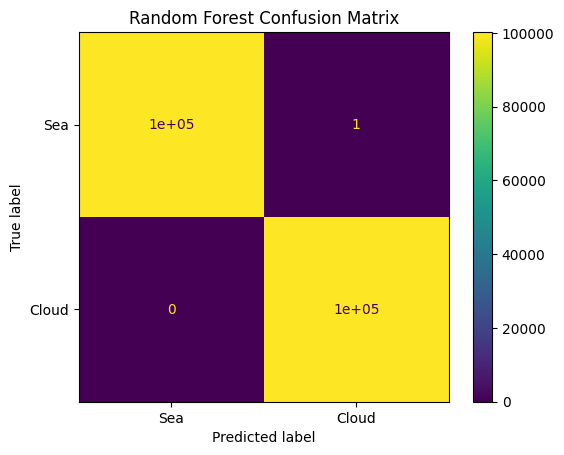

Saved Random Forest model to: /content/drive/MyDrive/AI/Week10/outputs/random_forest_cloud_sea_model.pkl


In [3]:
# Train and evaluate a Random Forest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# Folder where processed data and outputs are stored
data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Load balanced training and testing datasets
X_train = np.load(os.path.join(data_dir, 'X_train_balanced.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test_balanced.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train_balanced.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test_balanced.npy'))

print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Flatten 3 × 3 × 21 patches into one-dimensional feature vectors
# Random Forest needs 2D input: samples × features
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened X_train shape:", X_train_flat.shape)
print("Flattened X_test shape:", X_test_flat.shape)

# Define and train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train)

# Predict testing labels
y_pred_rf = rf_model.predict(X_test_flat)

# Evaluate model
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest test accuracy:", rf_accuracy)
print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf, target_names=['Sea', 'Cloud']))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Sea', 'Cloud']
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.savefig(os.path.join(data_dir, "rf_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save Random Forest model
rf_model_path = os.path.join(data_dir, 'random_forest_cloud_sea_model.pkl')

with open(rf_model_path, 'wb') as f:
    pickle.dump(rf_model, f)

print("Saved Random Forest model to:", rf_model_path)

### Apply the Random Forest model to the selected OLCI chunk

This section applies the trained Random Forest model to the full selected Sentinel-3 OLCI chunk. The resulting classification map is saved as a PNG file and can be compared with the CNN classification map.

Loaded chunk: /content/drive/MyDrive/AI/Week10/outputs/radiance_chunk_4.npy
Chunk shape: (818, 4865, 21)
Loaded Random Forest model: /content/drive/MyDrive/AI/Week10/outputs/random_forest_cloud_sea_model.pkl
Prediction input shape before flattening: (3968208, 3, 3, 21)
Prediction input shape after flattening: (3968208, 189)


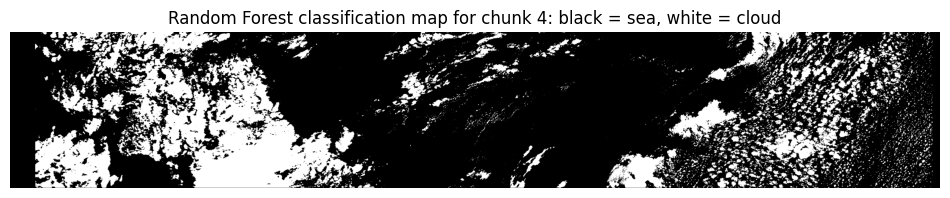

Saved Random Forest classification map to: /content/drive/MyDrive/AI/Week10/outputs/rf_classification_map_chunk_4.png


In [4]:
# Apply the trained Random Forest model to the selected OLCI chunk

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pickle
from matplotlib.colors import ListedColormap

# Folder where model and processed data are stored
data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Select the same chunk used for training
chunk_id = 4

# Load selected OLCI chunk
chunk_path = os.path.join(data_dir, f'radiance_chunk_{chunk_id}.npy')
chunk = np.load(chunk_path)

print("Loaded chunk:", chunk_path)
print("Chunk shape:", chunk.shape)

# Load trained Random Forest model
rf_model_path = os.path.join(data_dir, 'random_forest_cloud_sea_model.pkl')

with open(rf_model_path, 'rb') as f:
    rf_model = pickle.load(f)

print("Loaded Random Forest model:", rf_model_path)

# Extract 3 × 3 × 21 patches for the full selected chunk
x_full = []

for i in range(1, chunk.shape[0] - 1):
    for j in range(1, chunk.shape[1] - 1):
        patch = chunk[i-1:i+2, j-1:j+2, :]
        x_full.append(patch)

x_full = np.array(x_full)

print("Prediction input shape before flattening:", x_full.shape)

# Flatten patches for Random Forest
x_full_flat = x_full.reshape(x_full.shape[0], -1)

print("Prediction input shape after flattening:", x_full_flat.shape)

# Predict labels
rf_pred = rf_model.predict(x_full_flat)

# Reconstruct 2D classification map
rf_map = np.zeros((chunk.shape[0], chunk.shape[1]), dtype=np.uint8)
rf_map[1:-1, 1:-1] = rf_pred.reshape(chunk.shape[0] - 2, chunk.shape[1] - 2)

# Plot classification map
cmap = ListedColormap(['black', 'white'])

plt.figure(figsize=(12, 4))
plt.imshow(rf_map, cmap=cmap, vmin=0, vmax=1)
plt.title(f"Random Forest classification map for chunk {chunk_id}: black = sea, white = cloud")
plt.axis("off")
plt.show()

# Save classification map
rf_map_path = os.path.join(data_dir, f'rf_classification_map_chunk_{chunk_id}.png')
cv2.imwrite(rf_map_path, rf_map * 255)

print("Saved Random Forest classification map to:", rf_map_path)

### Gaussian Naive Bayes classification

This section trains a Gaussian Naive Bayes classifier as a simple baseline model. The same balanced training and testing datasets are used, but the 3 × 3 × 21 OLCI patches are flattened into one-dimensional feature vectors before classification. Model performance is evaluated using accuracy, a classification report and a confusion matrix.

Original X_train shape: (1804167, 3, 3, 21)
Original X_test shape: (200463, 3, 3, 21)
y_train shape: (1804167,)
y_test shape: (200463,)
Flattened X_train shape: (1804167, 189)
Flattened X_test shape: (200463, 189)
Gaussian Naive Bayes test accuracy: 0.9656395444545877
Gaussian Naive Bayes classification report:
              precision    recall  f1-score   support

         Sea       0.99      0.94      0.96    100232
       Cloud       0.94      0.99      0.97    100231

    accuracy                           0.97    200463
   macro avg       0.97      0.97      0.97    200463
weighted avg       0.97      0.97      0.97    200463



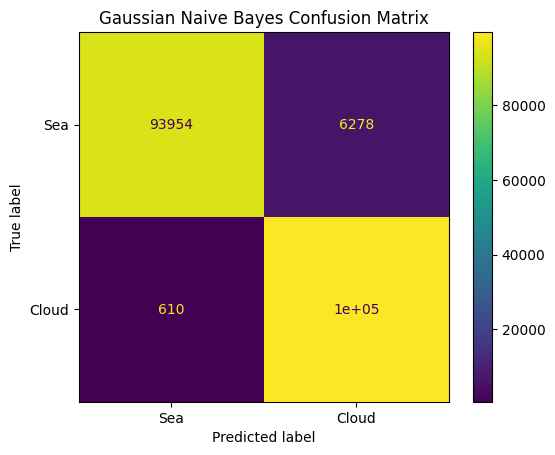

Saved Gaussian Naive Bayes model to: /content/drive/MyDrive/AI/Week10/outputs/gaussian_nb_cloud_sea_model.pkl


In [5]:
# Train and evaluate a Gaussian Naive Bayes classifier

import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Folder where processed data and outputs are stored
data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Load balanced training and testing datasets
X_train = np.load(os.path.join(data_dir, 'X_train_balanced.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test_balanced.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train_balanced.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test_balanced.npy'))

print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Flatten 3 × 3 × 21 patches into one-dimensional feature vectors
# Gaussian Naive Bayes needs 2D input: samples × features
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened X_train shape:", X_train_flat.shape)
print("Flattened X_test shape:", X_test_flat.shape)

# Train Gaussian Naive Bayes model
gnb_model = GaussianNB()
gnb_model.fit(X_train_flat, y_train)

# Predict testing labels
y_pred_gnb = gnb_model.predict(X_test_flat)

# Evaluate model
gnb_accuracy = accuracy_score(y_test, y_pred_gnb)

print("Gaussian Naive Bayes test accuracy:", gnb_accuracy)
print("Gaussian Naive Bayes classification report:")
print(classification_report(y_test, y_pred_gnb, target_names=['Sea', 'Cloud']))

# Confusion matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gnb,
    display_labels=['Sea', 'Cloud']
)

disp.plot()
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.savefig(os.path.join(data_dir, "gnb_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save Gaussian Naive Bayes model
gnb_model_path = os.path.join(data_dir, 'gaussian_nb_cloud_sea_model.pkl')

with open(gnb_model_path, 'wb') as f:
    pickle.dump(gnb_model, f)

print("Saved Gaussian Naive Bayes model to:", gnb_model_path)

### Gaussian Mixture Model classification

This section applies a Gaussian Mixture Model as an unsupervised baseline method. Unlike the CNN, Random Forest and Gaussian Naive Bayes models, GMM does not use class labels during training. The 3 × 3 × 21 OLCI patches are flattened into one-dimensional feature vectors, and the model separates the data into two clusters. The cluster labels are then aligned with the sea and cloud classes for evaluation.

Original X_train shape: (1804167, 3, 3, 21)
Original X_test shape: (200463, 3, 3, 21)
Flattened X_train shape: (1804167, 189)
Flattened X_test shape: (200463, 189)
GMM labels were flipped to match sea/cloud classes.
GMM test accuracy: 0.9147623252171223
GMM classification report:
              precision    recall  f1-score   support

         Sea       1.00      0.83      0.91    100232
       Cloud       0.85      1.00      0.92    100231

    accuracy                           0.91    200463
   macro avg       0.93      0.91      0.91    200463
weighted avg       0.93      0.91      0.91    200463



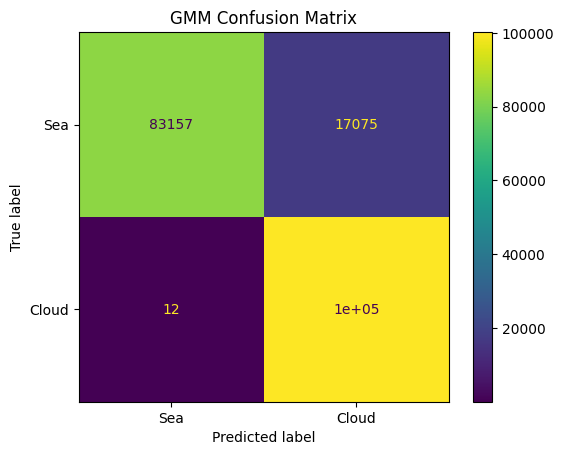

Saved GMM model to: /content/drive/MyDrive/AI/Week10/outputs/gmm_cloud_sea_model.pkl


In [3]:
# Train and evaluate a Gaussian Mixture Model classifier

import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Folder where processed data and outputs are stored
data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Load balanced training and testing datasets
X_train = np.load(os.path.join(data_dir, 'X_train_balanced.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test_balanced.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train_balanced.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test_balanced.npy'))

print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)

# Flatten 3 × 3 × 21 patches into one-dimensional feature vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened X_train shape:", X_train_flat.shape)
print("Flattened X_test shape:", X_test_flat.shape)

# Train GMM as an unsupervised model
gmm_model = GaussianMixture(
    n_components=2,
    covariance_type='diag',
    random_state=42
)

gmm_model.fit(X_train_flat)

# Predict cluster labels for the test set
y_pred_gmm = gmm_model.predict(X_test_flat)

# Align GMM cluster labels with real class labels
# GMM cluster numbers are arbitrary, so both label directions are tested.
acc_original = accuracy_score(y_test, y_pred_gmm)
acc_flipped = accuracy_score(y_test, 1 - y_pred_gmm)

if acc_flipped > acc_original:
    y_pred_gmm = 1 - y_pred_gmm
    gmm_accuracy = acc_flipped
    print("GMM labels were flipped to match sea/cloud classes.")
else:
    gmm_accuracy = acc_original

print("GMM test accuracy:", gmm_accuracy)
print("GMM classification report:")
print(classification_report(y_test, y_pred_gmm, target_names=['Sea', 'Cloud']))

# Confusion matrix
cm_gmm = confusion_matrix(y_test, y_pred_gmm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gmm,
    display_labels=['Sea', 'Cloud']
)

disp.plot()
plt.title("GMM Confusion Matrix")
plt.savefig(os.path.join(data_dir, "gmm_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save GMM model
gmm_model_path = os.path.join(data_dir, 'gmm_cloud_sea_model.pkl')

with open(gmm_model_path, 'wb') as f:
    pickle.dump(gmm_model, f)

print("Saved GMM model to:", gmm_model_path)

## K-means

### K-means classification

This section applies K-means clustering as an unsupervised baseline method. Unlike the CNN, Random Forest and Gaussian Naive Bayes models, K-means does not use class labels during training. The 3 × 3 × 21 OLCI patches are flattened into one-dimensional feature vectors, and the model separates the data into two clusters. The cluster labels are then aligned with the sea and cloud classes for evaluation.

Original X_train shape: (1804167, 3, 3, 21)
Original X_test shape: (200463, 3, 3, 21)
y_train shape: (1804167,)
y_test shape: (200463,)
Flattened X_train shape: (1804167, 189)
Flattened X_test shape: (200463, 189)
K-means test accuracy: 0.9736559863915036
K-means classification report:
              precision    recall  f1-score   support

         Sea       0.97      0.97      0.97    100232
       Cloud       0.97      0.97      0.97    100231

    accuracy                           0.97    200463
   macro avg       0.97      0.97      0.97    200463
weighted avg       0.97      0.97      0.97    200463



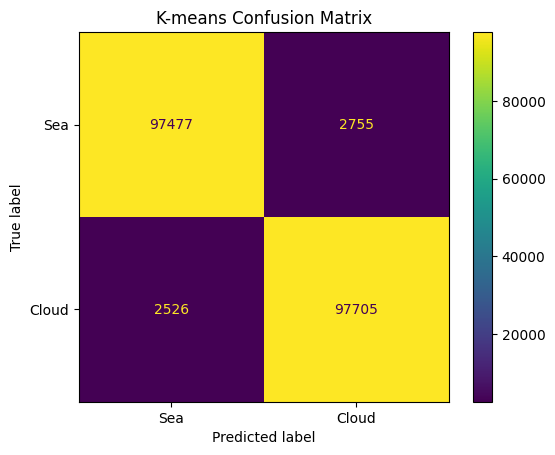

Saved K-means model to: /content/drive/MyDrive/AI/Week10/outputs/kmeans_cloud_sea_model.pkl


In [4]:
# Train and evaluate a K-means classifier

import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Folder where processed data and outputs are stored
data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

# Load balanced training and testing datasets
X_train = np.load(os.path.join(data_dir, 'X_train_balanced.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test_balanced.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train_balanced.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test_balanced.npy'))

print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Flatten 3 × 3 × 21 patches into one-dimensional feature vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened X_train shape:", X_train_flat.shape)
print("Flattened X_test shape:", X_test_flat.shape)

# Train K-means as an unsupervised model
kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_model.fit(X_train_flat)

# Predict cluster labels for the test set
y_pred_kmeans = kmeans_model.predict(X_test_flat)

# Align K-means cluster labels with real class labels
# K-means cluster numbers are arbitrary, so both label directions are tested.
acc_original = accuracy_score(y_test, y_pred_kmeans)
acc_flipped = accuracy_score(y_test, 1 - y_pred_kmeans)

if acc_flipped > acc_original:
    y_pred_kmeans = 1 - y_pred_kmeans
    kmeans_accuracy = acc_flipped
    print("K-means labels were flipped to match sea/cloud classes.")
else:
    kmeans_accuracy = acc_original

print("K-means test accuracy:", kmeans_accuracy)
print("K-means classification report:")
print(classification_report(y_test, y_pred_kmeans, target_names=['Sea', 'Cloud']))

# Confusion matrix
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_kmeans,
    display_labels=['Sea', 'Cloud']
)

disp.plot()
plt.title("K-means Confusion Matrix")
plt.savefig(os.path.join(data_dir, "kmeans_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save K-means model
kmeans_model_path = os.path.join(data_dir, 'kmeans_cloud_sea_model.pkl')

with open(kmeans_model_path, 'wb') as f:
    pickle.dump(kmeans_model, f)

print("Saved K-means model to:", kmeans_model_path)

## Model comparison

This section summarises the performance of the supervised and unsupervised classification models used in this project. Accuracy values were calculated using the balanced testing dataset generated from the selected Sentinel-3 OLCI chunk.

In [6]:
# Summarise model performance with accuracy values

import pandas as pd

model_results = {
    "Model": [
        "CNN",
        "Random Forest",
        "Gaussian Naive Bayes",
        "GMM",
        "K-means"
    ],
    "Learning type": [
        "Supervised deep learning",
        "Supervised machine learning",
        "Supervised baseline",
        "Unsupervised baseline",
        "Unsupervised baseline"
    ],
    "Accuracy": [
        0.9982,
        1.0000,
        0.9656,
        0.9148,
        0.9737
    ],
    "Main output": [
        "CNN classification map",
        "RF confusion matrix and classification map",
        "Confusion matrix",
        "Confusion matrix",
        "Confusion matrix"
    ],
    "Interpretation": [
        "Very high performance; used for spatial cloud classification",
        "Highest quantitative performance; used for spatial cloud classification",
        "Good simple supervised baseline",
        "Weakest baseline, but useful as an unsupervised comparison",
        "Best unsupervised baseline in this workflow"
    ]
}

results_df = pd.DataFrame(model_results)
results_df

,Model,Learning type,Accuracy,Main output,Interpretation
0,CNN,Supervised deep learning,0.9982,CNN classification map,Very high performance; used for spatial cloud ...
1,Random Forest,Supervised machine learning,1.0000,RF confusion matrix and classification map,Highest quantitative performance; used for spa...
2,Gaussian Naive Bayes,Supervised baseline,0.9656,Confusion matrix,Good simple supervised baseline
3,GMM,Unsupervised baseline,0.9148,Confusion matrix,"Weakest baseline, but useful as an unsupervise..."
4,K-means,Unsupervised baseline,0.9737,Confusion matrix,Best unsupervised baseline in this workflow


## Results interpretation

The supervised models performed best in this classification task. The Random Forest model achieved the highest testing accuracy, followed closely by the CNN model. This suggests that the labelled threshold mask provided a strong training signal for separating clear sea-surface pixels from cloud-covered pixels using the 21 Sentinel-3 OLCI spectral bands.

The Gaussian Naive Bayes model also performed well, although its accuracy was lower than the CNN and Random Forest models. This is expected because Gaussian Naive Bayes is a simpler statistical classifier and makes stronger assumptions about the feature distributions.

Among the unsupervised methods, K-means performed better than GMM. This indicates that the broad spectral contrast between dark sea surface and bright cloud pixels can be separated to some extent without labels. However, the supervised methods were more reliable because they were trained using labelled examples from the selected OLCI chunk.

### Check saved output files

This section checks whether the main classification maps, confusion matrices and trained model outputs have been saved successfully. These files are the main outputs used for the GitHub repository, result discussion and video explanation.

In [7]:
import os
import pandas as pd

data_dir = '/content/drive/MyDrive/AI/Week10/outputs/'

output_files = {
    "CNN classification map": "cnn_classification_map_chunk_4.png",
    "Random Forest classification map": "rf_classification_map_chunk_4.png",
    "Random Forest confusion matrix": "rf_confusion_matrix.png",
    "Gaussian NB confusion matrix": "gnb_confusion_matrix.png",
    "GMM confusion matrix": "gmm_confusion_matrix.png",
    "K-means confusion matrix": "kmeans_confusion_matrix.png"
}

file_check = []

for output_name, filename in output_files.items():
    file_check.append({
        "Output": output_name,
        "File": filename,
        "Status": "Saved" if os.path.exists(os.path.join(data_dir, filename)) else "Missing"
    })

file_check_df = pd.DataFrame(file_check)
file_check_df

,Output,File,Status
0,CNN classification map,cnn_classification_map_chunk_4.png,Saved
1,Random Forest classification map,rf_classification_map_chunk_4.png,Saved
2,Random Forest confusion matrix,rf_confusion_matrix.png,Saved
3,Gaussian NB confusion matrix,gnb_confusion_matrix.png,Saved
4,GMM confusion matrix,gmm_confusion_matrix.png,Saved
5,K-means confusion matrix,kmeans_confusion_matrix.png,Saved


# Conclusion

This project classified cloud-covered and clear sea-surface pixels using Sentinel-3 OLCI Level-1 EFR radiance data. The 21 OLCI radiance bands were converted from NetCDF files into a NumPy array and split into smaller chunks to reduce memory use. Chunk 4 was selected because it contained both clear sea-surface and cloud-covered areas.

A threshold-based binary mask was generated from a visible OLCI band and used to create labelled training and testing samples. The labelled pixels were converted into balanced 3 × 3 × 21 spectral-spatial patches. The final training and testing datasets were balanced between the sea and cloud classes, which helped reduce class imbalance during model training.

Several classification models were tested. The CNN and Random Forest models were used as the main supervised classifiers, while Gaussian Naive Bayes was included as a simple supervised baseline. GMM and K-means were tested as unsupervised baseline methods. The supervised models achieved the highest test accuracy, with Random Forest and CNN both performing very strongly. Among the unsupervised methods, K-means performed better than GMM.

The CNN and Random Forest models were also applied back to the selected OLCI chunk to produce spatial cloud classification maps. These outputs show that Sentinel-3 OLCI spectral information can be used to distinguish cloud-covered pixels from clear sea surface. However, the very high accuracy values should be interpreted carefully because the training and testing samples were generated from the same selected scene using an automatic threshold-based mask. Further testing on independent Sentinel-3 OLCI scenes from different dates and locations would be needed to assess how well the workflow generalises.
